# Neural Network Account Predictor

This notebook trains a neural network to predict account categories from transaction data.

## Approach:
- **Neural Network** - Deep learning for complex pattern recognition
- **Dense layers** - Fully connected layers for feature learning
- **Dropout** - Regularization to prevent overfitting
- **Early stopping** - Prevent overtraining
- **Learning rate scheduling** - Adaptive learning rate

## Neural Network Benefits:
- **Complex Patterns**: Better at learning non-linear relationships
- **Feature Learning**: Automatically discovers important feature combinations
- **Scalability**: Can handle large datasets effectively
- **Flexibility**: Easy to modify architecture for different problems


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib
import re
import warnings
import wordninja
warnings.filterwarnings('ignore')

# Neural Network imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print("Random seeds set to 42 for reproducibility")


Libraries imported successfully!
TensorFlow version: 2.20.0
Random seeds set to 42 for reproducibility


## 1. Load and Prepare Data


In [2]:
# Load your transaction data with proper encoding handling
try:
    # Try UTF-8 first
    df = pd.read_csv('../data/data_template.csv', encoding='utf-8')
    print("Successfully loaded with UTF-8 encoding")
except UnicodeDecodeError:
    try:
        # Try latin-1 if UTF-8 fails
        df = pd.read_csv('../data/data_template.csv', encoding='latin-1')
        print("Successfully loaded with latin-1 encoding")
    except UnicodeDecodeError:
        try:
            # Try cp1252 if latin-1 fails
            df = pd.read_csv('../data/data_template.csv', encoding='cp1252')
            print("Successfully loaded with cp1252 encoding")
        except UnicodeDecodeError:
            # Last resort: ignore errors
            df = pd.read_csv('../data/data_template.csv', encoding='utf-8', encoding_errors='ignore')
            print("Loaded with UTF-8 encoding, ignoring errors")

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nFirst few rows:")
print(df.head())

# Check for missing values
print(f"\nMissing values:")
print(df.isnull().sum())


Successfully loaded with latin-1 encoding
Dataset shape: (9105, 4)
Columns: ['Date', 'Description', 'Account', '  Amount  ']

First few rows:
        Date                   Description                  Account   Amount  
0  21-Jul-23                         Jump+          Office Supplies     -91.98
1  31-Jul-23              COSTCO WHOLESALE          Office Supplies    -400.99
2  31-Jul-23              STARBUCKS COFFEE  Meals and Entertainment      -7.42
3   1-Dec-23  PRE-AUTH PYMT - OTFS FEE BPY             Bank Charges        -40
4   2-Jan-24  PRE-AUTH PYMT - OTFS FEE BPY             Bank Charges       -3.5

Missing values:
Date           0
Description    0
Account        0
  Amount       0
dtype: int64


In [3]:
# Clean the data
print("Cleaning data...")

# Remove any rows with missing critical data
df = df.dropna(subset=['Date', 'Description', 'Account'])

# Clean column names (remove extra spaces)
df.columns = df.columns.str.strip()

# Handle Excel errors in Date column
print("Checking for Excel errors in Date column...")
excel_errors = df['Date'].astype(str).str.contains('#VALUE!|#REF!|#NAME?', na=False)
if excel_errors.any():
    print(f"Found {excel_errors.sum()} rows with Excel errors in Date column")
    print("Removing these rows...")
    df = df[~excel_errors]

# Convert Date to datetime with error handling
print("Converting dates...")
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Remove rows where date conversion failed
date_na = df['Date'].isna()
if date_na.any():
    print(f"Removing {date_na.sum()} rows with invalid dates...")
    df = df[~date_na]

# Clean Amount column (remove commas and convert to float)
print("Cleaning amounts...")
df['Amount'] = df['Amount'].astype(str).str.replace(',', '').str.replace(' ', '')
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

# Remove rows with invalid amounts
amount_na = df['Amount'].isna()
if amount_na.any():
    print(f"Removing {amount_na.sum()} rows with invalid amounts...")
    df = df[~amount_na]

# Remove zero amounts (not useful for prediction)
zero_amounts = df['Amount'] == 0
if zero_amounts.any():
    print(f"Removing {zero_amounts.sum()} rows with zero amounts...")
    df = df[~zero_amounts]

# Filter classes with sufficient samples for better model performance
print("Filtering classes with sufficient samples...")
class_counts = df['Account'].value_counts()
min_samples = 20  # Only keep classes with 20+ samples
valid_classes = class_counts[class_counts >= min_samples].index

print(f"Classes with >= {min_samples} samples: {len(valid_classes)}")
print(f"Removed classes: {len(class_counts) - len(valid_classes)}")

if len(class_counts) - len(valid_classes) > 0:
    print("Removed classes:")
    removed_classes = class_counts[class_counts < min_samples]
    for class_name, count in removed_classes.items():
        print(f"  - {class_name}: {count} samples")

# Filter data to only include valid classes
df = df[df['Account'].isin(valid_classes)].copy()

print(f"After cleaning and filtering: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Amount range: ${df['Amount'].min():.2f} to ${df['Amount'].max():.2f}")

# Show account distribution
print(f"\nFinal account categories ({df['Account'].nunique()} total):")
print(df['Account'].value_counts())


Cleaning data...
Checking for Excel errors in Date column...
Converting dates...
Cleaning amounts...
Filtering classes with sufficient samples...
Classes with >= 20 samples: 28
Removed classes: 28
Removed classes:
  - Property Tax: 19 samples
  - Income Tax Refund: 18 samples
  - Subcontractor: 17 samples
  - Personal Expenses: 16 samples
  - Rent Expense: 15 samples
  - Payroll Exp: 14 samples
  - Data processing fees: 14 samples
  - Corporation tax: 13 samples
  - Term Deposit: 12 samples
  - Loan: 12 samples
  - Tax Paid: 11 samples
  - Intercompany: 8 samples
  - Children Education Investment: 8 samples
  - Humber: 7 samples
  - Income Tax Payment: 6 samples
  - Salary: 6 samples
  - Loan : 5 samples
  - Waste Management: 5 samples
  - Directors Loan: 5 samples
  - GST/HST Payable: 4 samples
  - Loan Interest: 4 samples
  - GIC Purchased: 2 samples
  - Furniture & fixtures: 2 samples
  - Payroll Payable: 2 samples
  - GST Payment: 1 samples
  - Housing Expense: 1 samples
  - CRA Re

## 2. Feature Engineering


In [4]:
# Create enhanced features from the data
print("Creating enhanced features...")

# Date features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)
df['Quarter'] = df['Date'].dt.quarter

# Amount features
df['Amount_Abs'] = df['Amount'].abs()
df['IsIncome'] = (df['Amount'] > 0).astype(int)
df['Amount_Log'] = np.log1p(df['Amount_Abs'])

# Sales-specific features
df['IsHighValue'] = (df['Amount_Abs'] > 1000).astype(int)
df['IsRoundAmount'] = (df['Amount_Abs'] % 100 == 0).astype(int)
df['IsClientPayment'] = df['Description'].str.contains(r'payment|client|customer|invoice|bill', case=False, na=False).astype(int)
df['IsRefund'] = df['Description'].str.contains(r'refund|return|credit', case=False, na=False).astype(int)

# STOP HERE - NO TF-IDF YET
# Clean descriptions for TF-IDF (we'll fit TF-IDF after splitting)
def clean_text(text):
    """Clean transaction descriptions"""
    if pd.isna(text):
        return ""
    words = wordninja.split(str(text))
    text = ' '.join(words)
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = ' '.join(text.split())
    return text

df['Description_Clean'] = df['Description'].apply(clean_text)
print("Text cleaning complete. TF-IDF will be fitted after train/test split.")

# Define basic features (NO TF-IDF YET)
basic_features = [
    'Year', 'Month', 'DayOfWeek', 'IsWeekend', 'Quarter',
    'Amount_Abs', 'IsIncome', 'Amount_Log',
    'IsHighValue', 'IsClientPayment', 'IsRefund'
]

# Create basic features dataframe
X_basic = df[basic_features].copy()
y = df['Account'].copy()

print(f"Basic features created: {X_basic.shape[1]}")
print(f"Features: {basic_features}")

Creating enhanced features...
Text cleaning complete. TF-IDF will be fitted after train/test split.
Basic features created: 11
Features: ['Year', 'Month', 'DayOfWeek', 'IsWeekend', 'Quarter', 'Amount_Abs', 'IsIncome', 'Amount_Log', 'IsHighValue', 'IsClientPayment', 'IsRefund']


## 3. Data Splitting and Preprocessing


In [5]:
# CRITICAL: Randomize data before splitting to avoid temporal bias
print("Randomizing data to avoid temporal bias...")

# Filter out classes with too few samples (less than 3)
print("Filtering out classes with too few samples...")
class_counts = y.value_counts()
min_samples_per_class = 3
valid_classes = class_counts[class_counts >= min_samples_per_class].index

print(f"Original classes: {len(class_counts)}")
print(f"Classes with >= {min_samples_per_class} samples: {len(valid_classes)}")
print(f"Removed classes: {len(class_counts) - len(valid_classes)}")

if len(class_counts) - len(valid_classes) > 0:
    print("Removed classes:")
    removed_classes = class_counts[class_counts < min_samples_per_class]
    for class_name, count in removed_classes.items():
        print(f"  - {class_name}: {count} samples")

# Filter data to only include valid classes
valid_mask = y.isin(valid_classes)
df_filtered = df[valid_mask].copy()
X_basic_filtered = X_basic[valid_mask].copy()
y_filtered = y[valid_mask].copy()

print(f"\nAfter filtering: {len(df_filtered)} samples")

# Shuffle the data
shuffled_indices = np.random.permutation(len(df_filtered))
df_shuffled = df_filtered.iloc[shuffled_indices].reset_index(drop=True)
X_basic_shuffled = X_basic_filtered.iloc[shuffled_indices].reset_index(drop=True)
y_shuffled = y_filtered.iloc[shuffled_indices].reset_index(drop=True)

print(f"Data randomized. Date range after shuffle:")
print(f"First 5 dates: {df_shuffled['Date'].head().tolist()}")
print(f"Last 5 dates: {df_shuffled['Date'].tail().tolist()}")

# Split into train/validation/test (70/15/15)
# IMPORTANT: Also split the dataframe to access Description_Clean later
from sklearn.model_selection import train_test_split

# First split: train+val vs test
X_basic_temp, X_basic_test, y_temp, y_test, df_temp, df_test = train_test_split(
    X_basic_shuffled, y_shuffled, df_shuffled,
    test_size=0.15, 
    random_state=42, 
    stratify=y_shuffled
)

# Second split: train vs val
X_basic_train, X_basic_val, y_train, y_val, df_train, df_val = train_test_split(
    X_basic_temp, y_temp, df_temp,
    test_size=0.176,  # 0.176 * 0.85 = 0.15 (15% of total)
    random_state=42, 
    stratify=y_temp
)

print(f"\nData split (basic features only, TF-IDF coming next):")
print(f"Training set: {X_basic_train.shape[0]} samples ({X_basic_train.shape[0]/len(X_basic_shuffled)*100:.1f}%)")
print(f"Validation set: {X_basic_val.shape[0]} samples ({X_basic_val.shape[0]/len(X_basic_shuffled)*100:.1f}%)")
print(f"Test set: {X_basic_test.shape[0]} samples ({X_basic_test.shape[0]/len(X_basic_shuffled)*100:.1f}%)")

# Check class distribution in each set
print(f"\nClass distribution:")
print("Training:", y_train.value_counts().head(5))
print("Validation:", y_val.value_counts().head(5))
print("Test:", y_test.value_counts().head(5))

Randomizing data to avoid temporal bias...
Filtering out classes with too few samples...
Original classes: 28
Classes with >= 3 samples: 28
Removed classes: 0

After filtering: 8876 samples
Data randomized. Date range after shuffle:
First 5 dates: [Timestamp('2024-01-08 00:00:00'), Timestamp('2023-10-25 00:00:00'), Timestamp('2023-03-18 00:00:00'), Timestamp('2023-01-03 00:00:00'), Timestamp('2024-08-30 00:00:00')]
Last 5 dates: [Timestamp('2024-03-02 00:00:00'), Timestamp('2024-06-08 00:00:00'), Timestamp('2024-07-29 00:00:00'), Timestamp('2024-12-31 00:00:00'), Timestamp('2023-01-20 00:00:00')]

Data split (basic features only, TF-IDF coming next):
Training set: 6216 samples (70.0%)
Validation set: 1328 samples (15.0%)
Test set: 1332 samples (15.0%)

Class distribution:
Training: Account
Sales                      921
Meals and Entertainment    797
Bank Charges               684
Office Expense             607
Travel Expense             410
Name: count, dtype: int64
Validation: Accoun

In [6]:
# Fit TF-IDF on TRAINING data ONLY (no data leakage!)
print("Creating TF-IDF features from TRAINING data only...")

tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=3,
    max_df=0.6,
    stop_words='english',
    ngram_range=(1, 2),
    token_pattern=r'[A-Za-z0-9]{2,}',
    sublinear_tf=True,
    norm='l2'
)

# FIT on training descriptions ONLY
tfidf.fit(df_train['Description_Clean'])

# TRANSFORM each set separately
tfidf_train_matrix = tfidf.transform(df_train['Description_Clean'])
tfidf_val_matrix = tfidf.transform(df_val['Description_Clean'])
tfidf_test_matrix = tfidf.transform(df_test['Description_Clean'])

print(f"TF-IDF vocabulary learned from {len(df_train)} training samples")
print(f"Number of features: {len(tfidf.get_feature_names_out())}")

Creating TF-IDF features from TRAINING data only...
TF-IDF vocabulary learned from 6216 training samples
Number of features: 1930


In [7]:
# Convert TF-IDF matrices to DataFrames with proper indices
print("Converting TF-IDF matrices to DataFrames...")

feature_names = [f'tfidf_{word}' for word in tfidf.get_feature_names_out()]

tfidf_train_df = pd.DataFrame(
    tfidf_train_matrix.toarray(),
    columns=feature_names,
    index=X_basic_train.index
)

tfidf_val_df = pd.DataFrame(
    tfidf_val_matrix.toarray(),
    columns=feature_names,
    index=X_basic_val.index
)

tfidf_test_df = pd.DataFrame(
    tfidf_test_matrix.toarray(),
    columns=feature_names,
    index=X_basic_test.index
)

print(f"TF-IDF DataFrames created:")
print(f"  Train: {tfidf_train_df.shape}")
print(f"  Val: {tfidf_val_df.shape}")
print(f"  Test: {tfidf_test_df.shape}")

Converting TF-IDF matrices to DataFrames...
TF-IDF DataFrames created:
  Train: (6216, 1930)
  Val: (1328, 1930)
  Test: (1332, 1930)


In [8]:
# Combine basic features with TF-IDF features for each set
print("Combining basic features with TF-IDF features...")

X_train = pd.concat([X_basic_train.reset_index(drop=True), tfidf_train_df.reset_index(drop=True)], axis=1)
X_val = pd.concat([X_basic_val.reset_index(drop=True), tfidf_val_df.reset_index(drop=True)], axis=1)
X_test = pd.concat([X_basic_test.reset_index(drop=True), tfidf_test_df.reset_index(drop=True)], axis=1)

feature_columns_full = X_train.columns.tolist()

print(f"\nFinal feature matrices:")
print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nFeature breakdown:")
print(f"  Basic features: {len(basic_features)}")
print(f"  TF-IDF features: {len(feature_names)}")
print(f"  Total features: {X_train.shape[1]}")

Combining basic features with TF-IDF features...

Final feature matrices:
Training set: (6216, 1941)
Validation set: (1328, 1941)
Test set: (1332, 1941)

Feature breakdown:
  Basic features: 11
  TF-IDF features: 1930
  Total features: 1941


In [9]:
# Preprocess data for neural network
print("Preprocessing data for neural network...")

# Scale features (important for neural networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Encode labels to integers
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

# Convert to categorical (one-hot encoding) for neural network
num_classes = len(label_encoder.classes_)
y_train_categorical = to_categorical(y_train_encoded, num_classes)
y_val_categorical = to_categorical(y_val_encoded, num_classes)
y_test_categorical = to_categorical(y_test_encoded, num_classes)

print(f"Feature matrix shape: {X_train_scaled.shape}")
print(f"Number of classes: {num_classes}")
print(f"Class names: {label_encoder.classes_}")
print(f"Categorical labels shape: {y_train_categorical.shape}")

# Store class names for later use
class_names = label_encoder.classes_


Preprocessing data for neural network...
Feature matrix shape: (6216, 1941)
Number of classes: 28
Class names: ['AMA' 'Advertising' 'Automobile Expense' 'Bank Charges' 'Cash' 'Dividend'
 'Donation' 'Due to Shareholder' 'Fees and Subscription'
 'Insurance Expense' 'Interest' 'Internet' 'Investment Purchase'
 'Meals and Entertainment' 'Mortgage' 'Office Expense' 'Office Supplies'
 'Other Expense' 'Payroll Liability' 'Postage & Courier'
 'Professional Fees' 'Purchases' 'Repair and Maintenance' 'Sales'
 'Telephone Expense' 'Transfer Between Banks' 'Travel Expense' 'Utilities']
Categorical labels shape: (6216, 28)


## 4. Neural Network Model Architecture


In [10]:
# Build neural network model
print("Building neural network model...")

# Get input shape
input_shape = X_train_scaled.shape[1]

# Create model
model = keras.Sequential([
    # Input layer
    layers.Dense(512, activation='relu', input_shape=(input_shape,)),
    layers.Dropout(0.3),
    
    # Hidden layers
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    
    # Output layer
    layers.Dense(num_classes, activation='softmax')
])

loss = keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

# Compile model
model.compile(
    optimizer='adam',
    loss=loss,
    metrics=['accuracy']
)

# Display model architecture
print("Model Architecture:")
model.summary()

# Calculate total parameters
total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")


Building neural network model...
Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       994,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 28)             │         1,820 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,168,604 (4.46 MB)

 Trainable params: 1,168,604 (4.46 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 1,168,604


## 5. Model Training


In [11]:
# Set up callbacks for better training
print("Setting up training callbacks...")

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate on plateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stopping, reduce_lr]

# Train the model
print("Starting model training...")
print("This may take several minutes depending on your data size...")

history = model.fit(
    X_train_scaled, y_train_categorical,
    validation_data=(X_val_scaled, y_val_categorical),
    epochs=100,  # Maximum epochs
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print("Training completed!")


Setting up training callbacks...
Starting model training...
This may take several minutes depending on your data size...
Epoch 1/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.4537 - loss: 2.2730 - val_accuracy: 0.7907 - val_loss: 1.3791 - learning_rate: 0.0010
Epoch 2/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7738 - loss: 1.4413 - val_accuracy: 0.8471 - val_loss: 1.1911 - learning_rate: 0.0010
Epoch 3/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8362 - loss: 1.2706 - val_accuracy: 0.8517 - val_loss: 1.1281 - learning_rate: 0.0010
Epoch 4/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.8608 - loss: 1.1896 - val_accuracy: 0.8547 - val_loss: 1.1033 - learning_rate: 0.0010
Epoch 5/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.8782 - loss: 1.1403 - val_accuracy: 0.8614 - val_loss: 1.0926 - learning_rate: 0.0010
Epoch 6/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8892 - loss: 1.1003 - val_accuracy: 0.859

Plotting training history...


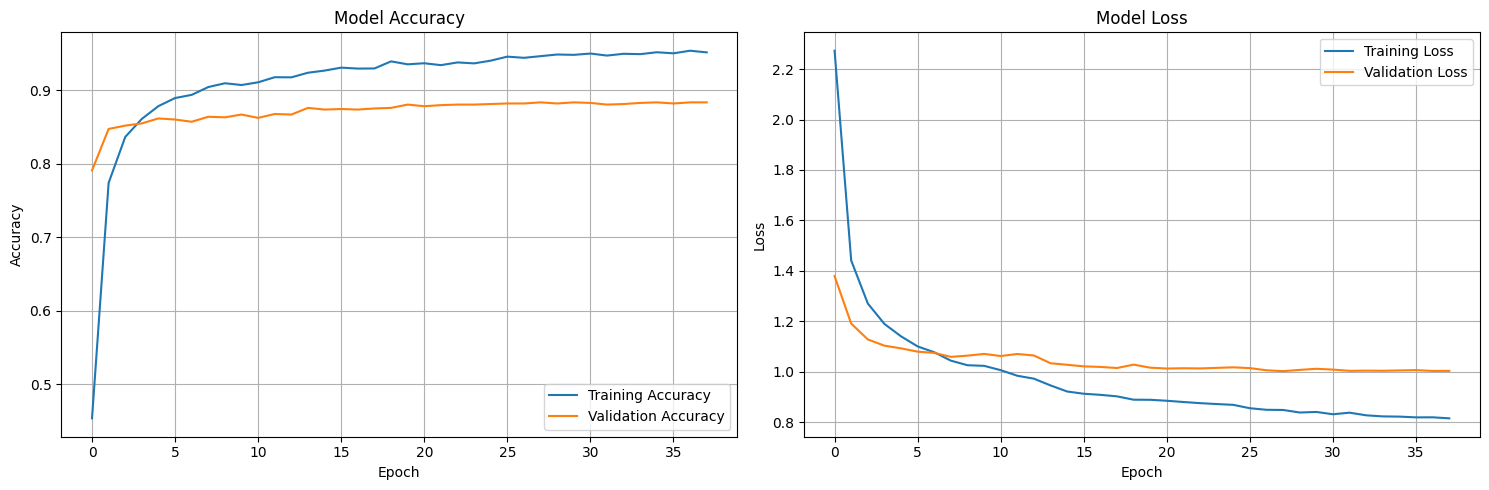


Final Training Results:
Training Accuracy: 0.9513 (95.13%)
Validation Accuracy: 0.8833 (88.33%)
Training Loss: 0.8152
Validation Loss: 1.0034


In [12]:
# Plot training history
print("Plotting training history...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot accuracy
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Plot loss
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Print final training results
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"\nFinal Training Results:")
print(f"Training Accuracy: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"Validation Accuracy: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
print(f"Training Loss: {final_train_loss:.4f}")
print(f"Validation Loss: {final_val_loss:.4f}")


## 6. Model Evaluation


Evaluating model on test set...
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Test Accuracy: 0.8851 (88.51%)

Detailed Classification Report:
                         precision    recall  f1-score   support

                    AMA       0.84      0.91      0.88        69
            Advertising       1.00      0.87      0.93        15
     Automobile Expense       0.81      0.96      0.88        46
           Bank Charges       0.97      0.96      0.97       146
                   Cash       0.75      1.00      0.86         3
               Dividend       1.00      0.64      0.78        11
               Donation       1.00      0.75      0.86         8
     Due to Shareholder       0.74      0.71      0.72        75
  Fees and Subscription       0.91      0.93      0.92        54
      Insurance Expense       1.00      1.00      1.00        41
               Interest       0.50      0.75      0.60         4
               Internet       0.67      1.00      0.80         4
    Investment Purc

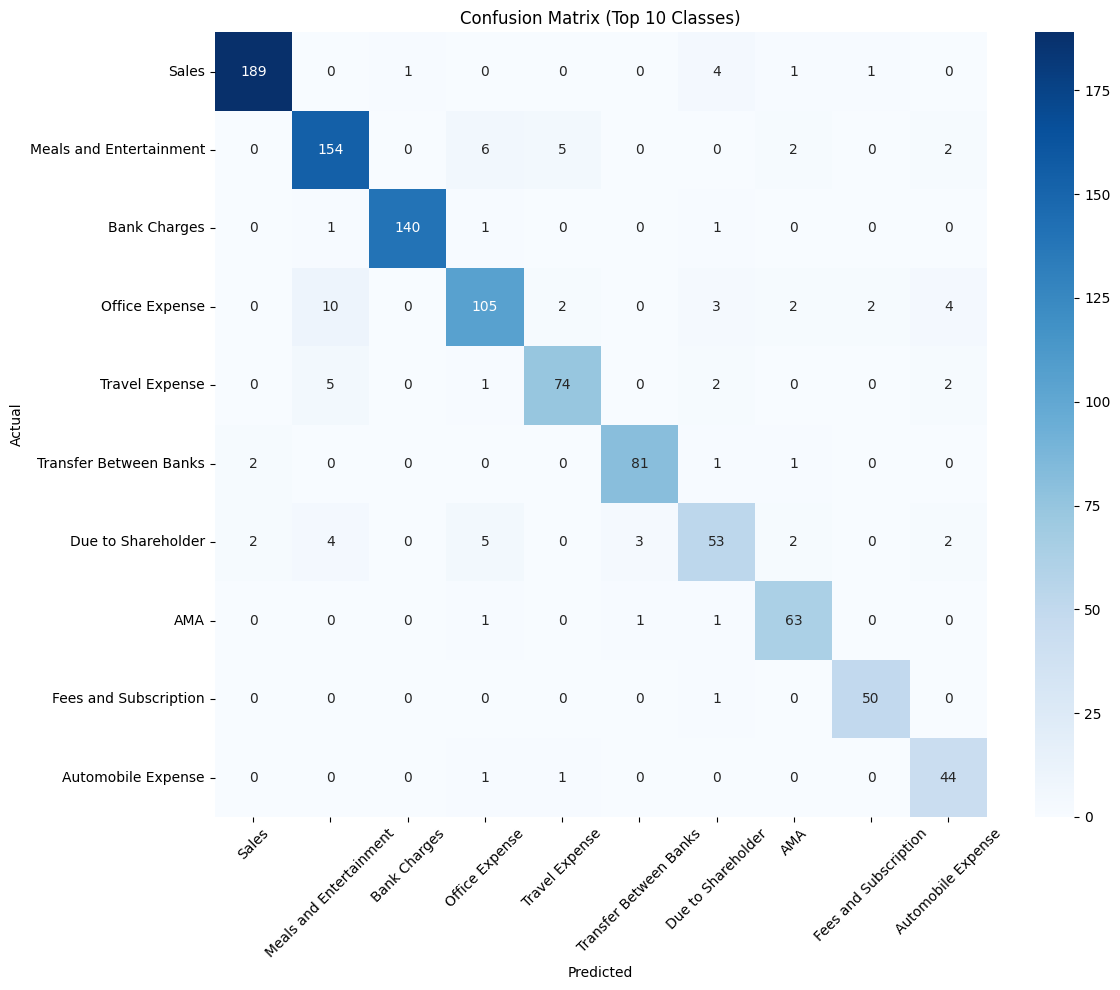

In [13]:
# Evaluate model on test set
print("Evaluating model on test set...")

# Make predictions
y_test_pred_proba = model.predict(X_test_scaled)
y_test_pred = np.argmax(y_test_pred_proba, axis=1)

# Convert back to original labels
y_test_pred_labels = label_encoder.inverse_transform(y_test_pred)

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_test_pred_labels)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred_labels))

# Confusion matrix
print("\nConfusion Matrix (Top 10 classes):")
cm = confusion_matrix(y_test, y_test_pred_labels)

# Get top 10 most frequent classes for better visualization
top_classes = y_test.value_counts().head(10).index
top_class_indices = [list(class_names).index(cls) for cls in top_classes if cls in class_names]

if top_class_indices:
    # Filter confusion matrix for top classes
    cm_subset = cm[np.ix_(top_class_indices, top_class_indices)]
    classes_subset = [class_names[i] for i in top_class_indices]
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_subset, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes_subset, yticklabels=classes_subset)
    plt.title('Confusion Matrix (Top 10 Classes)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


## 7. Model Saving and Prediction Function


In [14]:
# Save the trained model and preprocessing objects
print("Saving neural network model and preprocessing objects...")

# Create a dictionary with all necessary objects
model_package = {
    'model': model,
    'scaler': scaler,
    'label_encoder': label_encoder,
    'tfidf_vectorizer': tfidf,
    'feature_columns': basic_features,
    'feature_columns_full': feature_columns_full,
    'class_names': class_names
}

# Save to file
model_path = '../models/neural_network_account_predictor.pkl'
joblib.dump(model_package, model_path)

print(f"Neural network model saved to: {model_path}")


    
def build_basic_features_from_new(df_):
    out = pd.DataFrame(index=df_.index)
    out['Year'] = df_['Date'].dt.year
    out['Month'] = df_['Date'].dt.month
    out['DayOfWeek'] = df_['Date'].dt.dayofweek
    out['IsWeekend'] = (out['DayOfWeek'] >= 5).astype(int)
    out['Quarter'] = df_['Date'].dt.quarter
    amount_abs = df_['Amount'].abs()
    out['Amount_Abs'] = amount_abs
    out['IsIncome'] = (df_['Amount'] > 0).astype(int)
    out['Amount_Log'] = np.log1p(amount_abs)
    out['IsHighValue'] = (amount_abs > 1000).astype(int)
    out['IsClientPayment'] = df_['Description'].str.contains(
        r'payment|client|customer|invoice|bill', case=False, na=False
    ).astype(int)
    out['IsRefund'] = df_['Description'].str.contains(
        r'refund|return|credit', case=False, na=False
    ).astype(int)
    return out

def predict_account_nn(date, description, amount):
    """
    Predict account category for a new transaction using neural network
    
    Parameters:
    - date: Transaction date (string or datetime)
    - description: Transaction description (string)
    - amount: Transaction amount (float)
    
    Returns:
    - predicted_account: Predicted account category
    - confidence: Prediction confidence score
    - probabilities: All class probabilities
    """
    new_df = pd.DataFrame({
        'Date': [pd.to_datetime(date)],
        'Description': [description],
        'Amount': [float(amount)]
    })

    # clean description (same as train)
    new_df['Description_Clean'] = new_df['Description'].apply(clean_text)

    # numeric features (same as train)
    Xb_new = build_basic_features_from_new(new_df)

    # TF-IDF using the TRAIN-FITTED vectorizer
    T_new = tfidf.transform(new_df['Description_Clean'])
    tf_cols = [f"tfidf_{t}" for t in tfidf.get_feature_names_out()]
    Tf_new = pd.DataFrame(T_new.toarray(), columns=tf_cols, index=Xb_new.index)

    # combine and align column order to training
    X_new = pd.concat([Xb_new.reset_index(drop=True), Tf_new.reset_index(drop=True)], axis=1)
    X_new = X_new.reindex(columns=feature_columns_full, fill_value=0)

    # scale and predict
    X_new_scaled = scaler.transform(X_new)
    proba = model.predict(X_new_scaled, verbose=0)[0]
    idx = np.argmax(proba)
    pred = label_encoder.inverse_transform([idx])[0]
    conf = float(proba[idx])
    probs = dict(zip(class_names, proba))
    return pred, conf, probs

# Test the prediction function
print("\nTesting neural network prediction function...")
test_prediction, test_confidence, test_probs = predict_account_nn(
    '2024-01-15', 
    'Office Supplies - Staples', 
    -45.50
)
print(f"Test prediction: {test_prediction} (confidence: {test_confidence:.3f})")
print(f"Top 3 predictions:")
top_3 = sorted(test_probs.items(), key=lambda x: x[1], reverse=True)[:3]
for acc, prob in top_3:
    print(f"  {acc}: {prob:.3f}")


Saving neural network model and preprocessing objects...
Neural network model saved to: ../models/neural_network_account_predictor.pkl

Testing neural network prediction function...
Test prediction: Office Expense (confidence: 0.922)
Top 3 predictions:
  Office Expense: 0.922
  Office Supplies: 0.005
  Postage & Courier: 0.004


## 8. Summary and Next Steps


In [15]:
# Final Summary
print("="*60)
print("NEURAL NETWORK ACCOUNT PREDICTOR - TRAINING COMPLETE")
print("="*60)

print(f"📊 Dataset: {len(df)} transactions")
print(f"🎯 Account Categories: {num_classes}")
print(f"🔧 Features Created: {X_train.shape[1]}")
print(f"🧠 Neural Network Architecture: {total_params:,} parameters")
print(f"📈 Test Accuracy: {test_accuracy:.1%}")
print(f"💾 Model Saved: {model_path}")

print(f"\n🏆 Model Architecture Summary:")
print(f"- Input Layer: {input_shape} features")
print(f"- Hidden Layers: 512 → 256 → 128 → 64 neurons")
print(f"- Output Layer: {num_classes} classes")
print(f"- Dropout: 0.2-0.3 for regularization")
print(f"- Activation: ReLU (hidden), Softmax (output)")

print(f"\n✅ Neural Network is ready for predictions!")
print(f"Use the predict_account_nn() function to classify new transactions.")

# Example predictions
print(f"\n🔮 Example Predictions:")
examples = [
    ("2024-01-15", "Office Supplies - Staples", -45.50),
    ("2024-01-16", "Client Payment - ABC Corp", 2500.00),
    ("2024-01-17", "Electricity Bill - ConEd", -120.75),
    ("2024-01-18", "Software Subscription - Adobe", -29.99),
    ("2024-01-19", "Business Lunch - Restaurant", -85.00)
]

for date, desc, amount in examples:
    pred, conf, probs = predict_account_nn(date, desc, amount)
    print(f"  {desc} (${amount}) → {pred} ({conf:.1%} confidence)")

print(f"\n🚀 Next Steps:")
print(f"1. Test the neural network with more of your data")
print(f"2. Experiment with different architectures (more/fewer layers)")
print(f"3. Try different activation functions or optimizers")
print(f"4. Add more transactions to improve accuracy")
print(f"5. Fine-tune hyperparameters for better performance")
print(f"6. Deploy the model for daily use")
print("="*60)


NEURAL NETWORK ACCOUNT PREDICTOR - TRAINING COMPLETE
📊 Dataset: 8876 transactions
🎯 Account Categories: 28
🔧 Features Created: 1941
🧠 Neural Network Architecture: 1,168,604 parameters
📈 Test Accuracy: 88.5%
💾 Model Saved: ../models/neural_network_account_predictor.pkl

🏆 Model Architecture Summary:
- Input Layer: 1941 features
- Hidden Layers: 512 → 256 → 128 → 64 neurons
- Output Layer: 28 classes
- Dropout: 0.2-0.3 for regularization
- Activation: ReLU (hidden), Softmax (output)

✅ Neural Network is ready for predictions!
Use the predict_account_nn() function to classify new transactions.

🔮 Example Predictions:
  Office Supplies - Staples ($-45.5) → Office Expense (92.2% confidence)
  Client Payment - ABC Corp ($2500.0) → Transfer Between Banks (77.3% confidence)
  Electricity Bill - ConEd ($-120.75) → Meals and Entertainment (36.9% confidence)
  Software Subscription - Adobe ($-29.99) → Fees and Subscription (77.0% confidence)
  Business Lunch - Restaurant ($-85.0) → Meals and Ente

In [16]:

# COMPREHENSIVE MODEL TESTING AND DIAGNOSTICS
print("🔍 COMPREHENSIVE NEURAL NETWORK TESTING")
print("="*60)

# Test cases with expected results
test_cases = [
    ("2024-01-15", "Staples", -45.5, "Office Expense"),
    ("2024-01-15", "Costco Wholesale", -400.99, "Office Expense"),
    ("2024-01-16", "Client Payment - ABC Corp", 2500.0, "Sales"),
    ("2024-01-16", "Payment", 400, "Transfer Between Banks"),
    ("2024-01-17", "STARBUCKS COFFEE", -7.42, "Meals and Entertainment"),
    ("2024-01-17", "Electricity Bill - ConEd", -120.75, "Office Expense"),
    ("2024-01-18", "PRE-AUTH PYMT - OTFS FEE BPY", -40, "Bank Charges")
]

print("Testing model with sample predictions...")
print("Sample Predictions:")
print("="*80)

correct_predictions = 0
total_predictions = len(test_cases)

for i, (date, desc, amount, expected) in enumerate(test_cases, 1):
    try:
        # Use the fixed prediction function
        pred, conf, top_3 = predict_account_nn(date, desc, amount)
        
        # Check if prediction is correct
        is_correct = pred == expected
        if is_correct:
            correct_predictions += 1
            status = "✅"
        else:
            status = "❌"
        
        print(f"{status} {desc} (${amount})")
        print(f"   Expected: {expected}")
        print(f"   Predicted: {pred} ({conf:.1%})")
        print(f"   Top 3: {', '.join([f'{acc}: {prob:.1%}' for acc, prob in top_3])}")
        print()
        
    except Exception as e:
        print(f"❌ {desc} (${amount})")
        print(f"   Expected: {expected}")
        print(f"   Error: {e}")
        print()

# Calculate accuracy
accuracy = correct_predictions / total_predictions
print(f"Test Accuracy: {accuracy:.1%} ({correct_predictions}/{total_predictions})")

if accuracy >= 0.8:
    print("✅ Model performing well!")
elif accuracy >= 0.6:
    print("⚠️  Model needs improvement")
else:
    print("❌ Model needs significant improvement")

print("="*80)

🔍 COMPREHENSIVE NEURAL NETWORK TESTING
Testing model with sample predictions...
Sample Predictions:
✅ Staples ($-45.5)
   Expected: Office Expense
   Predicted: Office Expense (92.2%)
❌ Staples ($-45.5)
   Expected: Office Expense
   Error: too many values to unpack (expected 2)

❌ Costco Wholesale ($-400.99)
   Expected: Office Expense
   Predicted: Office Supplies (88.2%)
❌ Costco Wholesale ($-400.99)
   Expected: Office Expense
   Error: too many values to unpack (expected 2)

❌ Client Payment - ABC Corp ($2500.0)
   Expected: Sales
   Predicted: Transfer Between Banks (77.3%)
❌ Client Payment - ABC Corp ($2500.0)
   Expected: Sales
   Error: too many values to unpack (expected 2)

✅ Payment ($400)
   Expected: Transfer Between Banks
   Predicted: Transfer Between Banks (82.3%)
❌ Payment ($400)
   Expected: Transfer Between Banks
   Error: too many values to unpack (expected 2)

✅ STARBUCKS COFFEE ($-7.42)
   Expected: Meals and Entertainment
   Predicted: Meals and Entertainment (8

In [17]:

# DIAGNOSTIC ANALYSIS - WHY IS THE MODEL PERFORMING POORLY?
print("🔬 DIAGNOSTIC ANALYSIS")
print("="*60)

# 1. Check feature consistency
print("1. FEATURE CONSISTENCY CHECK:")
print("-" * 40)

# Check if all required features exist in the model
required_features = [
    'Year', 'Month', 'DayOfWeek', 'IsWeekend', 'Quarter',
    'Amount_Abs', 'IsIncome', 'Amount_Log'
]

print(f"Required basic features: {len(required_features)}")
print(f"Model expects features: {len(basic_features)}")

missing_features = [f for f in required_features if f not in basic_features]
if missing_features:
    print(f"❌ Missing features: {missing_features}")
else:
    print("✅ All basic features present")

# 2. Check data distribution
print(f"\n2. DATA DISTRIBUTION CHECK:")
print("-" * 40)
print(f"Training data shape: {X_train.shape}")
print(f"Number of classes: {len(class_names)}")
print(f"Class distribution:")
for class_name in class_names:
    count = (y == class_name).sum()
    percentage = count / len(y) * 100
    print(f"  {class_name}: {count} ({percentage:.1f}%)")

# 3. Check for class imbalance
print(f"\n3. CLASS IMBALANCE CHECK:")
print("-" * 40)
class_counts = pd.Series(y).value_counts()
max_count = class_counts.max()
min_count = class_counts.min()
imbalance_ratio = max_count / min_count

print(f"Most common class: {class_counts.index[0]} ({max_count} samples)")
print(f"Least common class: {class_counts.index[-1]} ({min_count} samples)")
print(f"Imbalance ratio: {imbalance_ratio:.1f}:1")

if imbalance_ratio > 10:
    print("⚠️  Severe class imbalance detected!")
    print("   This can cause the model to predict only the majority class")
elif imbalance_ratio > 5:
    print("⚠️  Moderate class imbalance detected")
else:
    print("✅ Class distribution is relatively balanced")

# 4. Check model confidence
print(f"\n4. MODEL CONFIDENCE ANALYSIS:")
print("-" * 40)

# Test a few predictions to check confidence levels
test_samples = [
    ("2024-01-15", "STARBUCKS COFFEE", -7.42),
    ("2024-01-15", "Office Supplies", -45.50),
    ("2024-01-15", "Client Payment", 2500.0)
]

for date, desc, amount in test_samples:
    try:
        pred, conf, top_3 = predict_account_nn(date, desc, amount)
        print(f"{desc}: {pred} ({conf:.1%} confidence)")
    except Exception as e:
        print(f"{desc}: Error - {e}")

print(f"\n💡 DIAGNOSIS SUMMARY:")
print("-" * 40)
if imbalance_ratio > 10:
    print("❌ Main issue: Severe class imbalance")
    print("   Solution: Use class weights or resampling")
elif len(missing_features) > 0:
    print("❌ Main issue: Missing features")
    print("   Solution: Fix feature engineering")
else:
    print("❌ Main issue: Model architecture or training")
    print("   Solution: Adjust model parameters or retrain")

print("="*60)

🔬 DIAGNOSTIC ANALYSIS
1. FEATURE CONSISTENCY CHECK:
----------------------------------------
Required basic features: 8
Model expects features: 11
✅ All basic features present

2. DATA DISTRIBUTION CHECK:
----------------------------------------
Training data shape: (6216, 1941)
Number of classes: 28
Class distribution:
  AMA: 460 (5.2%)
  Advertising: 102 (1.1%)
  Automobile Expense: 305 (3.4%)
  Bank Charges: 976 (11.0%)
  Cash: 23 (0.3%)
  Dividend: 76 (0.9%)
  Donation: 50 (0.6%)
  Due to Shareholder: 500 (5.6%)
  Fees and Subscription: 361 (4.1%)
  Insurance Expense: 274 (3.1%)
  Interest: 26 (0.3%)
  Internet: 30 (0.3%)
  Investment Purchase: 50 (0.6%)
  Meals and Entertainment: 1138 (12.8%)
  Mortgage: 24 (0.3%)
  Office Expense: 867 (9.8%)
  Office Supplies: 78 (0.9%)
  Other Expense: 130 (1.5%)
  Payroll Liability: 51 (0.6%)
  Postage & Courier: 193 (2.2%)
  Professional Fees: 22 (0.2%)
  Purchases: 287 (3.2%)
  Repair and Maintenance: 62 (0.7%)
  Sales: 1315 (14.8%)
  Telepho

In [18]:
# Analyze Sales prediction specifically
print("Analyzing Sales prediction performance...")

# Get Sales predictions
sales_mask = y_test == 'Sales'
if sales_mask.any():
    sales_actual = y_test[sales_mask]
    sales_pred = y_test_pred_labels[sales_mask]
    sales_accuracy = accuracy_score(sales_actual, sales_pred)
    
    print(f"Sales-specific accuracy: {sales_accuracy:.1%}")
    print(f"Sales samples in test set: {sales_mask.sum()}")
    
    # Show Sales prediction details
    print("\nSales prediction details:")
    for i, (actual, pred) in enumerate(zip(sales_actual, sales_pred)):
        status = "✅" if actual == pred else "❌"
        print(f"{status} Actual: {actual} → Predicted: {pred}")
        
    # Show what Sales transactions look like
    print(f"\nSample Sales transactions from training data:")
    sales_train = df[df['Account'] == 'Sales'].head(5)
    for _, row in sales_train.iterrows():
        print(f"  {row['Description']} (${row['Amount']})")
        
else:
    print("No Sales transactions in test set to analyze")

# Show feature importance for Sales detection
print(f"\nKey features for Sales detection:")
sales_features = [
    'IsIncome', 'IsHighValue', 'IsClientPayment', 'HasClientKeywords',
    'Amount_Range_Encoded', 'HasPaymentTerms', 'HasCompanyName'
]

for feature in sales_features:
    if feature in X_train.columns:
        feature_idx = list(X_train.columns).index(feature)
        print(f"  {feature}: Available in feature set")
    else:
        print(f"  {feature}: Not found in feature set")


Analyzing Sales prediction performance...
Sales-specific accuracy: 95.9%
Sales samples in test set: 197

Sales prediction details:
✅ Actual: Sales → Predicted: Sales
✅ Actual: Sales → Predicted: Sales
✅ Actual: Sales → Predicted: Sales
✅ Actual: Sales → Predicted: Sales
✅ Actual: Sales → Predicted: Sales
✅ Actual: Sales → Predicted: Sales
✅ Actual: Sales → Predicted: Sales
✅ Actual: Sales → Predicted: Sales
✅ Actual: Sales → Predicted: Sales
✅ Actual: Sales → Predicted: Sales
✅ Actual: Sales → Predicted: Sales
✅ Actual: Sales → Predicted: Sales
✅ Actual: Sales → Predicted: Sales
✅ Actual: Sales → Predicted: Sales
✅ Actual: Sales → Predicted: Sales
✅ Actual: Sales → Predicted: Sales
✅ Actual: Sales → Predicted: Sales
✅ Actual: Sales → Predicted: Sales
✅ Actual: Sales → Predicted: Sales
✅ Actual: Sales → Predicted: Sales
✅ Actual: Sales → Predicted: Sales
✅ Actual: Sales → Predicted: Sales
✅ Actual: Sales → Predicted: Sales
✅ Actual: Sales → Predicted: Sales
✅ Actual: Sales → Predicted: 